# Label-source ablation — test results

Compares synthetic_intent distillation runs (gpt-oss-120b → gemma-3-12b, lr=2e-5) under several training-data variants. The first three conditions form the label-source ablation; the last two are appendix-only comparators added for context.

**Label-source ablation:**

- **hard_human** — main-sweep adapter, hard subset (n≈1378) with 5-level human labels.
- **hard_original** — same hard subset, but with the original WildGuardMix binary labels.
- **random_original** — random size-matched WG sample (n≈1378), original binary labels.

**Appendix comparators (broader data sources):**

- **broader_intent_mix_synthetic** — annotated synthetic_intent (n=1378) + harm-stratified random WG synthetic_intent (n=1378). See `submit_broader_intent_mix.py`.
- **wildguardmix_full** — full WildGuardMix train split (~86.7k examples, 1 epoch). See `submit_scaling.py`.

The `hard_human` vs `hard_original` delta isolates the relabeling effect; `hard_original` vs `random_original` isolates the hard-subset effect. The last two place the small-data ablation conditions on the same scale as broader data sources.

Each row of the main table is a held-out evaluation dataset; columns are the conditions plus their pairwise deltas vs `hard_human`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("../../").resolve()

# Test eval output roots — see configs/experiments/ablations/label_source_ablation.yaml
# and configs/experiments/scaling/data_scaling.yaml.
ABLATION_TEST_ROOT = PROJECT_ROOT / "data" / "safety_experiment" / "distillation-ablations"
SCALING_TEST_ROOT  = PROJECT_ROOT / "data" / "safety_experiment" / "distillation-scaling"
BASELINE_TEST_DIR  = PROJECT_ROOT / "data" / "safety_experiment" / "distillation" / "openai-gpt-oss-120b" / "gemma-3-12b" / "synthetic_intent"

# Dataset slug → display name. Order is also the row order in the table.
DATASETS = {
    "annotated-intents": "Annotated Intents",
    "wildguardmix":      "WildGuardMix",
    "xstest":            "XSTest",
    "toxic-chat":        "Toxic Chat",
    "aegis":             "Aegis",
    "openai-moderation": "OpenAI Moderation",
}

# Condition slug → (display name, test results dir).
CONDITIONS = {
    "hard_human":      ("Hard subset · human labels (baseline)", BASELINE_TEST_DIR),
    "hard_original":   ("Hard subset · WG labels",                ABLATION_TEST_ROOT / "hard_original"),
    "random_original": ("Random WG · WG labels",                  ABLATION_TEST_ROOT / "random_original"),
    "broader_intent_mix_synthetic": (
        "Annotated + Random WG · synth intents",
        ABLATION_TEST_ROOT / "broader_intent_mix_synthetic",
    ),
    "wildguardmix_full": (
        "Full WildGuardMix · synth intents",
        SCALING_TEST_ROOT / "full_wg",
    ),
}

# Held-out average excludes annotated-intents (its val split was used for adapter selection).
HELD_OUT_DATASETS = [d for d in DATASETS if d != "annotated-intents"]

In [2]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def harm_f1(records: list[dict]) -> tuple[float, int]:
    """Binary harm F1 (positive = harmful). Returns (f1, n_records).

    Mirrors the convention in submit_distillation_eval.compute_ood_val_f1:
    parse failures (missing predicted_harm) are treated as 'safe', so models
    that ramble past max_new_tokens without producing a label are penalised.
    """
    tp = fp = tn = fn = 0
    for r in records:
        true_harm = (r.get("true_harm_binary") or r.get("true_harm") or "").lower()
        if not true_harm:
            continue
        pred_harm = (r.get("predicted_harm") or "safe").lower()
        if true_harm == "harmful" and pred_harm == "harmful":
            tp += 1
        elif true_harm == "safe" and pred_harm == "harmful":
            fp += 1
        elif true_harm == "safe" and pred_harm == "safe":
            tn += 1
        elif true_harm == "harmful" and pred_harm == "safe":
            fn += 1
    n = tp + fp + tn + fn
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return f1, n


def find_jsonl(dataset_dir: Path) -> Path | None:
    """Each test eval drops one *.jsonl file per dataset directory."""
    if not dataset_dir.exists():
        return None
    candidates = list(dataset_dir.glob("*.jsonl"))
    if not candidates:
        return None
    return candidates[0]


def load_condition_f1(condition_dir: Path) -> dict[str, tuple[float, int]]:
    """{dataset_slug -> (f1, n)} for one condition."""
    out = {}
    for ds_slug in DATASETS:
        jpath = find_jsonl(condition_dir / ds_slug)
        if jpath is None:
            continue
        out[ds_slug] = harm_f1(load_jsonl(jpath))
    return out

In [3]:
# Load all three conditions. Conditions whose test eval has not been run yet
# are kept in the index but show NaN — that way a partial run is still readable.
rows = []
for cond_slug, (cond_label, cond_dir) in CONDITIONS.items():
    per_ds = load_condition_f1(cond_dir)
    if not per_ds:
        print(f"[warn] no test results found for '{cond_slug}' under {cond_dir}")
    for ds_slug, ds_label in DATASETS.items():
        f1, n = per_ds.get(ds_slug, (np.nan, 0))
        rows.append({
            "condition_slug": cond_slug,
            "condition":      cond_label,
            "dataset_slug":   ds_slug,
            "dataset":        ds_label,
            "f1":             f1,
            "n":              n,
        })

long_df = pd.DataFrame(rows)
long_df.head(len(DATASETS) * len(CONDITIONS))

,condition_slug,condition,dataset_slug,dataset,f1,n
0,hard_human,Hard subset · human labels (baseline),annotated-intents,Annotated Intents,0.738095,173
1,hard_human,Hard subset · human labels (baseline),wildguardmix,WildGuardMix,0.874121,1699
2,hard_human,Hard subset · human labels (baseline),xstest,XSTest,0.908257,450
3,hard_human,Hard subset · human labels (baseline),toxic-chat,Toxic Chat,0.689815,5083
4,hard_human,Hard subset · human labels (baseline),aegis,Aegis,0.812815,1964
5,hard_human,Hard subset · human labels (baseline),openai-moderation,OpenAI Moderation,0.774518,1680
6,hard_original,Hard subset · WG labels,annotated-intents,Annotated Intents,0.757062,173
7,hard_original,Hard subset · WG labels,wildguardmix,WildGuardMix,0.872681,1699
8,hard_original,Hard subset · WG labels,xstest,XSTest,0.888889,450
9,hard_original,Hard subset · WG labels,toxic-chat,Toxic Chat,0.676409,5083


## Per-dataset test F1 with pairwise deltas

Rows are held-out evaluation datasets plus two summary rows:

- **Held-out mean** — average across all datasets except `annotated-intents` (whose val split was used for adapter selection).
- **All datasets mean** — including `annotated-intents` for reference.

Pairwise deltas are reported as `<condition> − hard_human` (positive = ablation beats baseline).

In [4]:
f1_pivot = long_df.pivot(index="dataset_slug", columns="condition_slug", values="f1")
f1_pivot = f1_pivot.reindex(index=list(DATASETS), columns=list(CONDITIONS))

# Append two summary rows at the bottom.
summary_rows = pd.DataFrame({
    cond: [
        f1_pivot.loc[HELD_OUT_DATASETS, cond].mean(skipna=True),
        f1_pivot.loc[list(DATASETS), cond].mean(skipna=True),
    ]
    for cond in CONDITIONS
}, index=["__held_out_mean__", "__all_mean__"])

table = pd.concat([f1_pivot, summary_rows])

# Pairwise deltas vs the hard_human baseline (every non-baseline condition).
if "hard_human" in table.columns:
    for cond_slug in CONDITIONS:
        if cond_slug == "hard_human" or cond_slug not in table.columns:
            continue
        table[f"{cond_slug} − hard_human"] = table[cond_slug] - table["hard_human"]

# Friendly row labels.
row_label_map = {**DATASETS, "__held_out_mean__": "Held-out mean (excl. annotated-intents)", "__all_mean__": "All-datasets mean"}
table.index = [row_label_map[i] for i in table.index]
table.columns = [
    CONDITIONS[c][0] if c in CONDITIONS else c
    for c in table.columns
]
table.index.name = "Dataset"

print("Test harm F1 per dataset (rows) × condition (columns)")
display(
    table.style.format("{:.3f}", na_rep="—")
        .background_gradient(subset=[c for c in table.columns if c in [v[0] for v in CONDITIONS.values()]], cmap="Greens", vmin=0.5, vmax=1.0)
        .background_gradient(subset=[c for c in table.columns if c.endswith("− hard_human") or c.endswith("hard_human")], cmap="RdBu", vmin=-0.1, vmax=0.1)
)

Test harm F1 per dataset (rows) × condition (columns)


,Hard subset · human labels (baseline),Hard subset · WG labels,Random WG · WG labels,Annotated + Random WG · synth intents,Full WildGuardMix · synth intents,hard_original − hard_human,random_original − hard_human,broader_intent_mix_synthetic − hard_human,wildguardmix_full − hard_human
Dataset,,,,,,,,,
Annotated Intents,0.738,0.757,0.754,0.760,0.704,0.019,0.016,0.022,-0.034
WildGuardMix,0.874,0.873,0.886,0.882,0.895,-0.001,0.012,0.008,0.021
XSTest,0.908,0.889,0.915,0.934,0.951,-0.019,0.006,0.026,0.043
Toxic Chat,0.690,0.676,0.726,0.689,0.711,-0.013,0.036,-0.001,0.021
Aegis,0.813,0.815,0.827,0.814,0.832,0.002,0.014,0.001,0.019
OpenAI Moderation,0.775,0.741,0.788,0.771,0.741,-0.034,0.014,-0.004,-0.033
Held-out mean (excl. annotated-intents),0.812,0.799,0.828,0.818,0.826,-0.013,0.016,0.006,0.014
All-datasets mean,0.800,0.792,0.816,0.808,0.806,-0.008,0.016,0.009,0.006


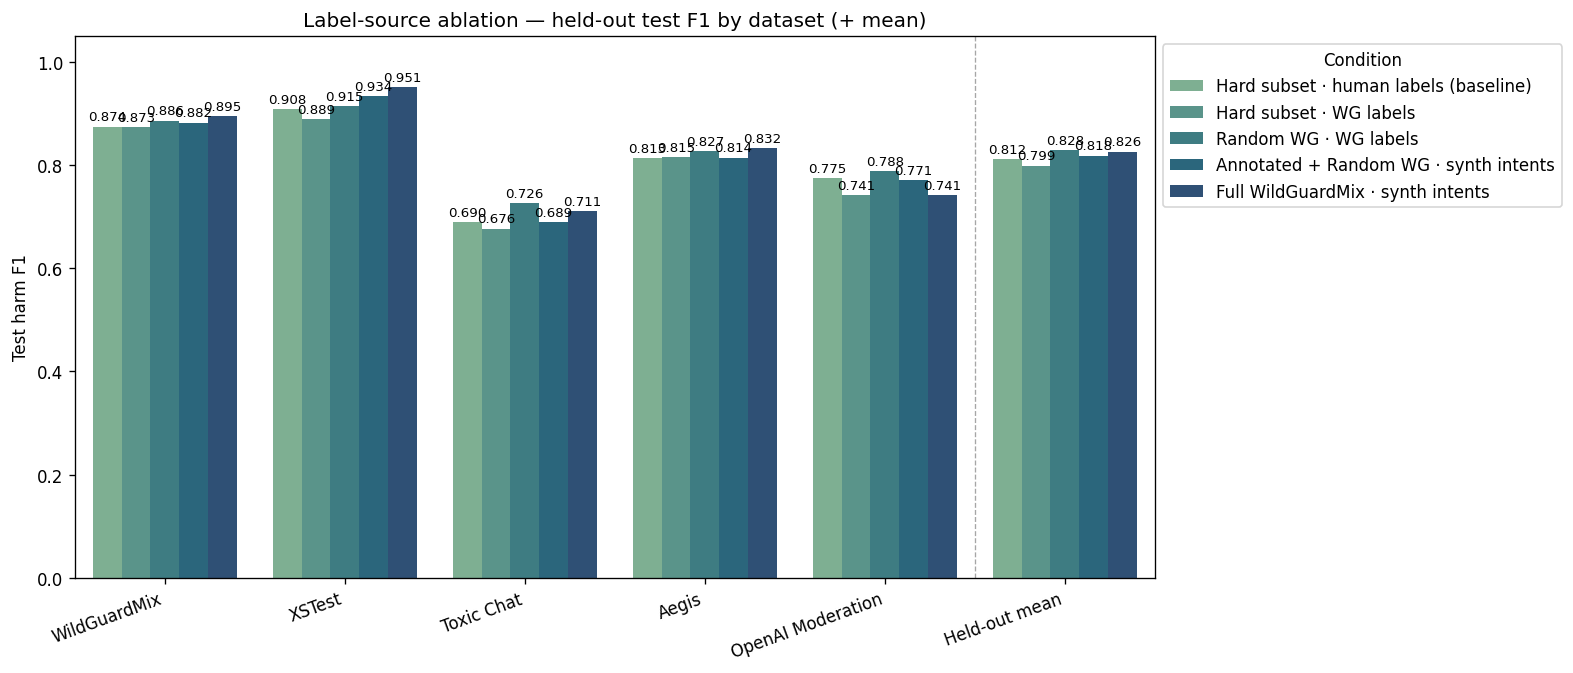

In [5]:
# Per-dataset bar plot — test F1 by condition (held-out datasets only).
# annotated-intents is excluded since its val split was used for adapter selection;
# the rightmost group is the mean across all bars shown.
HELD_OUT_LABEL = "Held-out mean"

plot_df = long_df[long_df["dataset_slug"].isin(HELD_OUT_DATASETS)].copy()

held_out_means = (
    plot_df.groupby(["condition_slug", "condition"], as_index=False)["f1"]
    .mean()
    .assign(dataset_slug="__held_out_mean__", dataset=HELD_OUT_LABEL, n=0)
)
plot_df = pd.concat([plot_df, held_out_means], ignore_index=True)

dataset_order = [DATASETS[d] for d in HELD_OUT_DATASETS] + [HELD_OUT_LABEL]
condition_order = [CONDITIONS[c][0] for c in CONDITIONS]
plot_df["dataset"]   = pd.Categorical(plot_df["dataset"],   categories=dataset_order,   ordered=True)
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=condition_order, ordered=True)

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
sns.barplot(
    data=plot_df,
    x="dataset",
    y="f1",
    hue="condition",
    palette="crest",
    ax=ax,
    errorbar=None,
)

# Numeric labels above each bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8, rotation=0)

# Visually separate the held-out summary from the per-dataset bars.
sep_x = len(HELD_OUT_DATASETS) - 0.5
ax.axvline(sep_x, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_ylabel("Test harm F1")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.set_title("Label-source ablation — held-out test F1 by dataset (+ mean)")
ax.legend(title="Condition", bbox_to_anchor=(1.0, 1.0), loc="upper left")
for label in ax.get_xticklabels():
    label.set_rotation(20)
    label.set_ha("right")
plt.show()

## Held-out mean comparison

Single-number summary per condition: mean test F1 across all evaluation datasets except the in-distribution `annotated-intents` test split.

,condition,held_out_mean_f1,delta_vs_hard_human
0,Hard subset · human labels (baseline),0.8119,+0.0000
1,Hard subset · WG labels,0.7987,-0.0132
2,Random WG · WG labels,0.8282,+0.0163
3,Annotated + Random WG · synth intents,0.8180,+0.0061
4,Full WildGuardMix · synth intents,0.8260,+0.0141


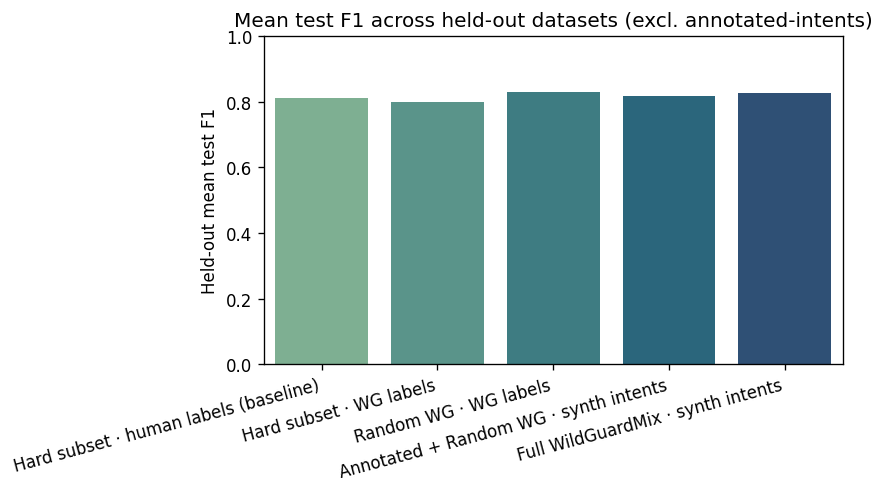

In [6]:
mean_df = (
    long_df[long_df["dataset_slug"].isin(HELD_OUT_DATASETS)]
    .groupby(["condition_slug", "condition"], as_index=False)["f1"]
    .mean()
    .rename(columns={"f1": "held_out_mean_f1"})
)
mean_df["condition_slug"] = pd.Categorical(
    mean_df["condition_slug"], categories=list(CONDITIONS), ordered=True,
)
mean_df = mean_df.sort_values("condition_slug").reset_index(drop=True)

# Pairwise deltas vs hard_human.
if "hard_human" in mean_df["condition_slug"].values:
    baseline_f1 = mean_df.loc[mean_df["condition_slug"] == "hard_human", "held_out_mean_f1"].iloc[0]
    mean_df["delta_vs_hard_human"] = mean_df["held_out_mean_f1"] - baseline_f1

display(
    mean_df[["condition", "held_out_mean_f1"] + (["delta_vs_hard_human"] if "delta_vs_hard_human" in mean_df.columns else [])]
        .style.format({
            "held_out_mean_f1": "{:.4f}",
            "delta_vs_hard_human": "{:+.4f}",
        }, na_rep="—")
)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
sns.barplot(
    data=mean_df,
    x="condition",
    y="held_out_mean_f1",
    palette="crest",
    hue="condition",
    legend=False,
    ax=ax,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Held-out mean test F1")
ax.set_xlabel("")
ax.set_title("Mean test F1 across held-out datasets (excl. annotated-intents)")
for label in ax.get_xticklabels():
    label.set_rotation(15)
    label.set_ha("right")
plt.show()

## Raw record counts

Sanity check that every condition was evaluated on the same number of records per dataset (mismatch would indicate a partial run).

In [7]:
n_pivot = long_df.pivot(index="dataset_slug", columns="condition_slug", values="n")
n_pivot = n_pivot.reindex(index=list(DATASETS), columns=list(CONDITIONS))
n_pivot.index = [DATASETS[i] for i in n_pivot.index]
n_pivot.columns = [CONDITIONS[c][0] for c in n_pivot.columns]
n_pivot.index.name = "Dataset"
display(n_pivot.fillna(0).astype(int))

,Hard subset · human labels (baseline),Hard subset · WG labels,Random WG · WG labels,Annotated + Random WG · synth intents,Full WildGuardMix · synth intents
Dataset,,,,,
Annotated Intents,173,173,173,173,173
WildGuardMix,1699,1699,1699,1699,1699
XSTest,450,450,450,450,450
Toxic Chat,5083,5083,5083,5083,5083
Aegis,1964,1964,1964,1964,1964
OpenAI Moderation,1680,1680,1680,1680,1680
